#  Healthcare Data Analysis using Python

## Project Overview

This project analyzes healthcare visit data to understand patient trends, revenue performance, operational efficiency, and patient satisfaction. Using Python, Pandas, Matplotlib, and Seaborn, the dataset is explored to generate meaningful insights that can help hospital management improve decision-making and resource planning.


## Project Objectives

- Explore the healthcare dataset using Python.
- Analyze monthly patient visit trends.
- Evaluate monthly revenue performance.
- Identify the top revenue-generating services and departments.
- Analyze patient satisfaction and waiting times.
- Visualize key business metrics using charts.

## Dataset Loading

##Tools and Libraries Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Healthcare_Analytics_Dataset.xlsx", sheet_name = "Fact_Visits", header =1)


In [8]:
print(df.head())

  VisitID        Date PatientID ServiceID DoctorID ClinicID  Fee_Charged  \
0   V5001  2022-01-01      P063    SVC008   DOC001   CLN001          450   
1   V5002  2022-01-01      P071    SVC009   DOC006   CLN004         2500   
2   V5003  2022-01-01      P033    SVC004   DOC002   CLN002          600   
3   V5004  2022-01-01      P062    SVC005   DOC010   CLN005         1500   
4   V5005  2022-01-01      P002    SVC012   DOC009   CLN002          700   

   Discount_Pct  Revenue  Insurance_Claimed  Out_of_Pocket  Wait_Time_Mins  \
0             0    450.0              225.0          225.0              36   
1            15   2125.0             1487.5          637.5              47   
2             0    600.0              480.0          120.0              73   
3             0   1500.0                0.0         1500.0              29   
4             0    700.0                0.0          700.0              75   

   Satisfaction_Score Follow_Up_Required   Visit_Type  
0                 

In [9]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10307 entries, 0 to 10306
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   VisitID             10307 non-null  object 
 1   Date                10307 non-null  object 
 2   PatientID           10307 non-null  object 
 3   ServiceID           10307 non-null  object 
 4   DoctorID            10307 non-null  object 
 5   ClinicID            10307 non-null  object 
 6   Fee_Charged         10307 non-null  int64  
 7   Discount_Pct        10307 non-null  int64  
 8   Revenue             10307 non-null  float64
 9   Insurance_Claimed   10307 non-null  float64
 10  Out_of_Pocket       10307 non-null  float64
 11  Wait_Time_Mins      10307 non-null  int64  
 12  Satisfaction_Score  10307 non-null  int64  
 13  Follow_Up_Required  10307 non-null  object 
 14  Visit_Type          10307 non-null  object 
dtypes: float64(3), int64(4), object(8)
memory usage: 1.2+

In [10]:
df.describe()



,Fee_Charged,Discount_Pct,Revenue,Insurance_Claimed,Out_of_Pocket,Wait_Time_Mins,Satisfaction_Score
count,10307.000000,10307.000000,10307.000000,10307.000000,10307.000000,10307.000000,10307.000000
mean,1111.123508,2.524983,1082.716843,358.458038,724.258805,48.083244,3.911225
std,610.672450,4.351640,597.273835,468.345329,580.899553,24.692620,1.000280
min,350.000000,0.000000,297.500000,0.000000,59.500000,5.000000,1.000000
25%,600.000000,0.000000,600.000000,0.000000,300.000000,27.000000,3.000000
50%,1000.000000,0.000000,1000.000000,0.000000,540.000000,48.000000,4.000000
75%,1500.000000,5.000000,1500.000000,600.000000,1000.000000,69.000000,5.000000
max,2500.000000,15.000000,2500.000000,2000.000000,2500.000000,90.000000,5.000000


In [11]:
df.shape



(10307, 15)

In [12]:
df.columns

Index(['VisitID', 'Date', 'PatientID', 'ServiceID', 'DoctorID', 'ClinicID',
       'Fee_Charged', 'Discount_Pct', 'Revenue', 'Insurance_Claimed',
       'Out_of_Pocket', 'Wait_Time_Mins', 'Satisfaction_Score',
       'Follow_Up_Required', 'Visit_Type'],
      dtype='object')

## Summary Statistics

In [13]:
def summary():
    print(f"Dataset Shape      : {df.shape}")
    print(f"Number of Rows     : {df.shape[0]}")
    print(f"Number of Columns  : {df.shape[1]}")

summary()

Dataset Shape      : (10307, 15)
Number of Rows     : 10307
Number of Columns  : 15


In [14]:
print(f"Total Visits             : {df['VisitID'].count():,}")
print(f"Total Revenue            : ₹{df['Revenue'].sum():,.2f}")
print(f"Average Revenue          : ₹{df['Revenue'].mean():,.2f}")
print(f"Average Wait Time        : {df['Wait_Time_Mins'].mean():.2f} minutes")
print(f"Average Satisfaction     : {df['Satisfaction_Score'].mean():.2f}")

Total Visits             : 10,307
Total Revenue            : ₹11,159,562.50
Average Revenue          : ₹1,082.72
Average Wait Time        : 48.08 minutes
Average Satisfaction     : 3.91


In [51]:
print(df.isnull().sum())



VisitID               0
Date                  0
PatientID             0
ServiceID             0
DoctorID              0
ClinicID              0
Fee_Charged           0
Discount_Pct          0
Revenue               0
Insurance_Claimed     0
Out_of_Pocket         0
Wait_Time_Mins        0
Satisfaction_Score    0
Follow_Up_Required    0
Visit_Type            0
month                 0
dtype: int64


In [50]:
print(f"Duplicate Records: {df.duplicated().sum()}")


Duplicate Records: 0


## 1. Monthly Visit Count Trend

### Objective

Analyze the monthly patient visit trend to identify seasonal patterns and fluctuations in hospital visits.

In [15]:
df["Date"] = pd.to_datetime(df["Date"])

df["month"] = df["Date"].dt.month_name()

monthly_visits = df.groupby("month").size()

month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

monthly_visits = monthly_visits.reindex(month_order)

average_visits = monthly_visits.mean()

print(monthly_visits)
print(average_visits)








month
January      828
February     851
March        833
April        831
May          877
June         893
July         791
August       982
September    842
October      844
November     849
December     886
dtype: int64
858.9166666666666


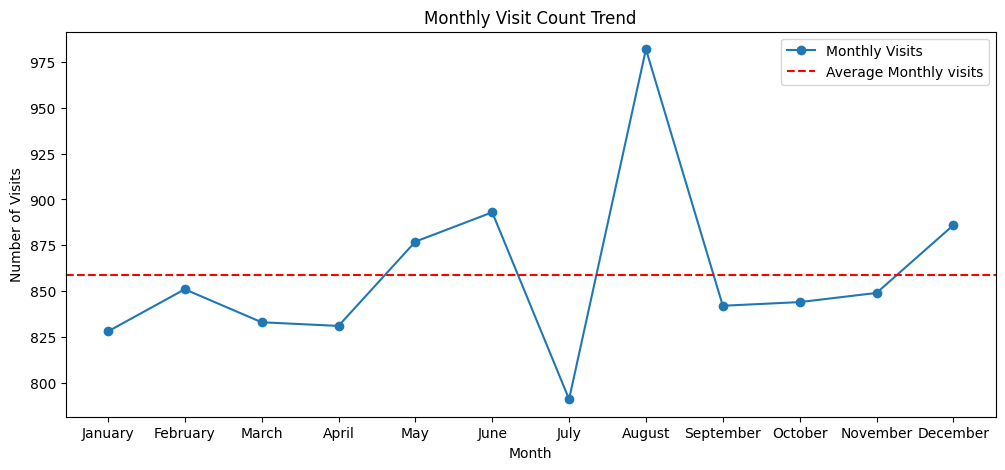

In [16]:
plt.figure(figsize=(12,5))

plt.plot(monthly_visits.index,
         monthly_visits.values,
         marker="o",
         label= "Monthly Visits")

plt.axhline(y=average_visits,
            color="red",
            linestyle="--",
            label="Average Monthly visits")

plt.title("Monthly Visit Count Trend")
plt.xlabel("Month")
plt.ylabel("Number of Visits")
plt.legend()
plt.show()

### Business Insight

Patient visits fluctuate throughout the year. August recorded the highest number of visits, while July had the lowest. Several months performed above the annual average, indicating periods of higher patient demand that may require additional staffing and resource planning.

## 2. Monthly Revenue Trend with Rolling Averages

### Objective

Compare monthly revenue with 3-month and 6-month rolling averages to identify the underlying revenue trend and reduce the effect of short-term fluctuations.

In [17]:
monthly_revenue =df.groupby("month")["Revenue"].sum()

monthly_revenue = monthly_revenue.reindex(month_order)


print(monthly_revenue)



month
January       890352.5
February      914272.5
March         912817.5
April         883475.0
May           967430.0
June          971417.5
July          842795.0
August       1068737.5
September     914422.5
October       893265.0
November      928480.0
December      972097.5
Name: Revenue, dtype: float64


In [18]:
rolling_3_month =monthly_revenue.rolling(window=3).mean()
rolling_6_month =monthly_revenue.rolling(window=6).mean()

print(rolling_3_month)
print(rolling_6_month)


month
January                NaN
February               NaN
March        905814.166667
April        903521.666667
May          921240.833333
June         940774.166667
July         927214.166667
August       960983.333333
September    941985.000000
October      958808.333333
November     912055.833333
December     931280.833333
Name: Revenue, dtype: float64
month
January                NaN
February               NaN
March                  NaN
April                  NaN
May                    NaN
June         923294.166667
July         915367.916667
August       941112.083333
September    941379.583333
October      943011.250000
November     936519.583333
December     936632.916667
Name: Revenue, dtype: float64


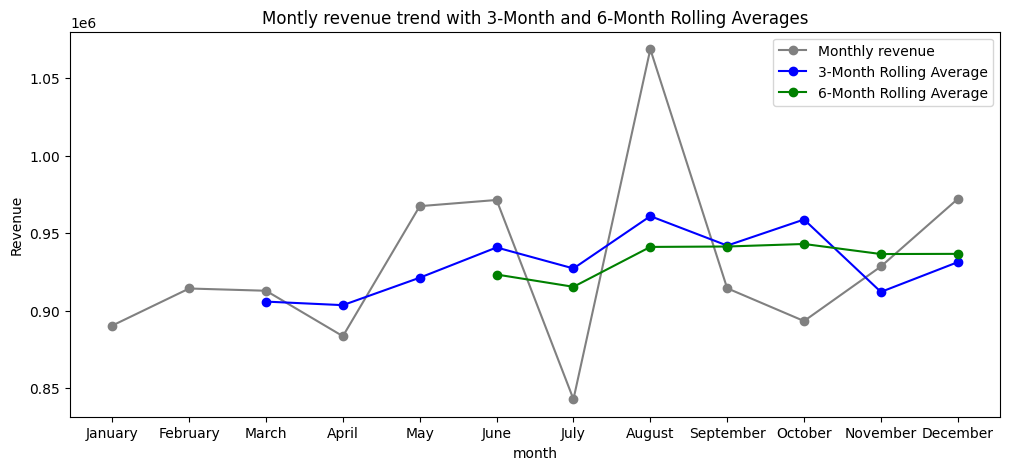

In [19]:
plt.figure(figsize=(12,5))

plt.plot(monthly_revenue,
         marker = "o",
         color ="gray",
         label ="Monthly revenue")

plt.plot(monthly_revenue.index,
         rolling_3_month.values,
         marker = "o",
         color ="blue",
         label ="3-Month Rolling Average")

plt.plot(monthly_revenue.index,
         rolling_6_month.values,
         marker = "o",
         color ="green",
         label ="6-Month Rolling Average")

plt.title("Montly revenue trend with 3-Month and 6-Month Rolling Averages")
plt.xlabel("month")
plt.ylabel("Revenue")
plt.legend()
plt.show()

### Business Insight

The monthly revenue shows noticeable fluctuations across the year. The 3-month rolling average follows recent changes more closely, while the 6-month rolling average provides a smoother long-term trend. Comparing these lines helps distinguish short-term variation from the overall revenue pattern.

## 3. Top 5 Services by Revenue

### Objective

Identify the top five healthcare services generating the highest revenue to understand which services contribute the most to the hospital's overall income.

In [20]:
dim_services = pd.read_excel(
    "Healthcare_Analytics_Dataset.xlsx",
    sheet_name="Dim_Services",
    header=1
)

In [21]:
merged_df = pd.merge(df, dim_services, on="ServiceID")

merged_df.head()

,VisitID,Date,PatientID,ServiceID,DoctorID,ClinicID,Fee_Charged,Discount_Pct,Revenue,Insurance_Claimed,...,Satisfaction_Score,Follow_Up_Required,Visit_Type,month,Service_Name,Department,Category,Fee,Primary_Doctor,Duration
0,V5001,2022-01-01,P063,SVC008,DOC001,CLN001,450,0,450.0,225.0,...,4,No,Walk-in,January,Vaccination,Preventive,Immunization,450,Nurse Team,15 mins
1,V5002,2022-01-01,P071,SVC009,DOC006,CLN004,2500,15,2125.0,1487.5,...,4,No,Walk-in,January,Ultrasound Scan,Diagnostics,Radiology,2500,Dr. Reddy,45 mins
2,V5003,2022-01-01,P033,SVC004,DOC002,CLN002,600,0,600.0,480.0,...,5,Yes,Walk-in,January,Chest X-Ray,Diagnostics,Radiology,600,Radiology Team,30 mins
3,V5004,2022-01-01,P062,SVC005,DOC010,CLN005,1500,0,1500.0,0.0,...,4,No,Walk-in,January,Dental Cleaning,Dental,Preventive,1500,Dr. Sharma,45 mins
4,V5005,2022-01-01,P002,SVC012,DOC009,CLN002,700,0,700.0,0.0,...,4,Yes,Appointment,January,Pediatric Check-Up,Pediatrics,Consultation,700,Dr. Krishnan,30 mins


In [22]:
service_revenue = merged_df.groupby("Service_Name")["Revenue"].sum()

service_revenue =service_revenue.sort_values(ascending=False)

top_5_services = service_revenue.head(5)

print(top_5_services)

Service_Name
Ultrasound Scan              1634125.0
Dental Filling               1312100.0
Mental Health Counselling    1171080.0
Dental Cleaning              1011225.0
Specialist Consultation      1006500.0
Name: Revenue, dtype: float64


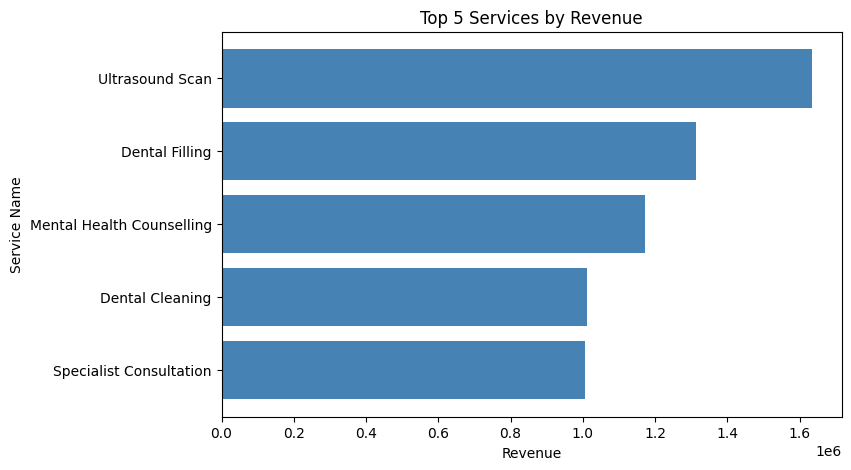

In [37]:
plt.figure(figsize=(8,5))
plt.barh(top_5_services.index,
         top_5_services.values,
         color="steelblue")
plt.gca().invert_yaxis()



plt.title("Top 5 Services by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Service Name")
plt.show()

### Business Insight

The chart highlights the five highest revenue-generating healthcare services. These services contribute significantly to the hospital's overall revenue and may represent areas where continued investment and operational focus can maximize financial performance.

## 4. Revenue by Department

### Objective

Analyze revenue generated by each department to identify the departments contributing the most to the hospital's overall revenue.

In [24]:
merged_df = pd.merge(df, dim_services, on="ServiceID")

merged_df.head()

department_revenue = merged_df.groupby("Department")["Revenue"].sum()

department_revenue = department_revenue.sort_values(ascending=False)

print(department_revenue)

Department
Diagnostics      3356955.0
Dental           2323325.0
OPD              1617960.0
Mental Health    1171080.0
Dermatology       792840.0
Physiotherapy     649350.0
Ophthalmology     478485.0
Pediatrics        454230.0
Preventive        315337.5
Name: Revenue, dtype: float64


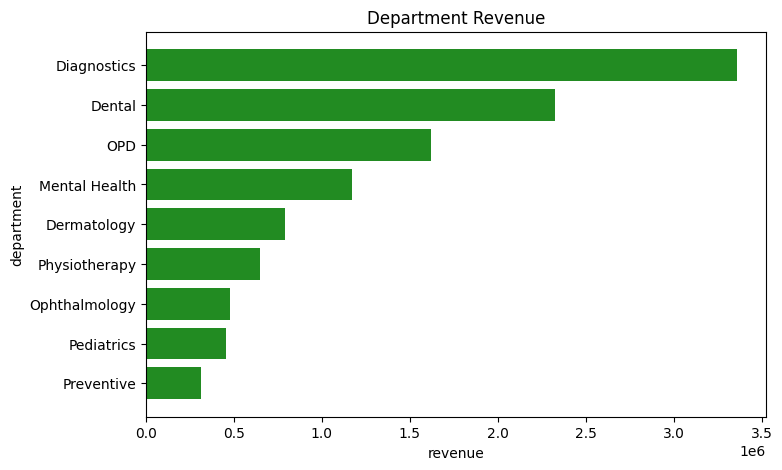

In [40]:
plt.figure(figsize=(8,5))
plt.barh(department_revenue.index,
         department_revenue.values,
         color= "forestgreen")
plt.gca().invert_yaxis()


plt.title("Department Revenue")
plt.xlabel("revenue")
plt.ylabel("department")
plt.show()

### Business Insight

The chart compares revenue generated across hospital departments. Departments with higher revenue contribute significantly to the hospital's financial performance, while departments with lower revenue may require further analysis to understand patient demand and service utilization.

## 5. Visit Count by Month and Department

### Objective

Analyze the distribution of patient visits across departments and months to identify periods of high and low patient demand.

In [26]:
heatmap_data = merged_df.pivot_table(
    index="Department",
    columns="month",
    values="VisitID",
    aggfunc="count"
)

print(heatmap_data)

month          April  August  December  February  January  July  June  March  \
Department                                                                     
Dental           113     134       124        98       98    86   119    126   
Dermatology       44      75        71        48       51    57    57     54   
Diagnostics      212     237       209       218      231   229   241    217   
Mental Health     56      64        49        69       44    41    70     53   
OPD              167     215       191       194      166   174   168    161   
Ophthalmology     64      61        57        62       65    50    60     49   
Pediatrics        60      73        64        55       66    42    48     61   
Physiotherapy     42      61        57        53       51    49    64     58   
Preventive        73      62        64        54       56    63    66     54   

month          May  November  October  September  
Department                                        
Dental         12

In [27]:
heatmap_data = heatmap_data.reindex(columns=month_order)

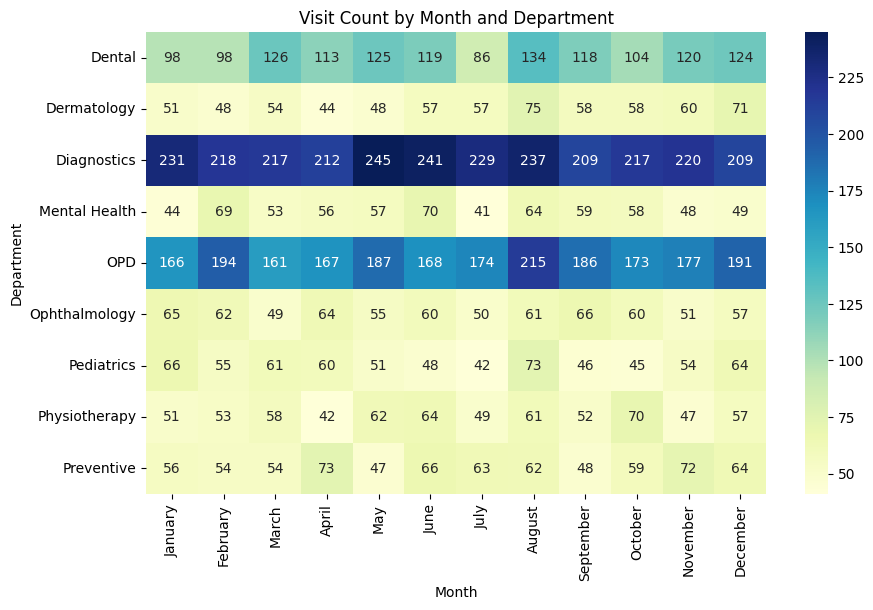

In [28]:
plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".0f"
)

plt.title("Visit Count by Month and Department")
plt.xlabel("Month")
plt.ylabel("Department")

plt.show()

### Business Insight

Diagnostics consistently records the highest patient visit counts across most months, followed by OPD. These departments experience greater patient demand and may require higher staffing levels and resource allocation to maintain efficient patient care.

## 6. Satisfaction Score Distribution

### Objective

Analyze the distribution of patient satisfaction scores to understand the overall patient experience.

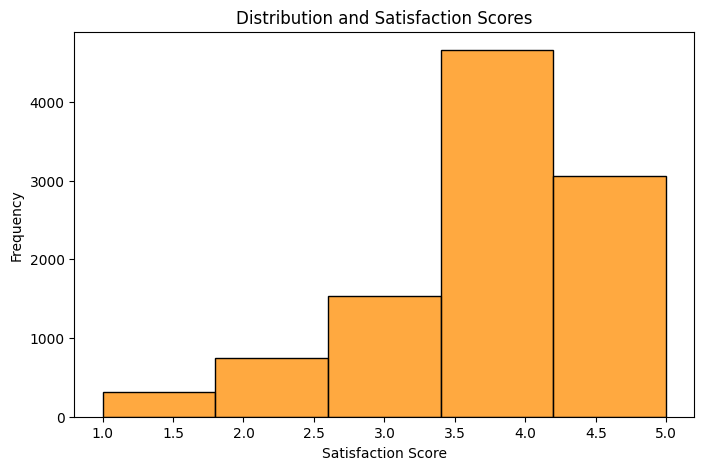

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Satisfaction_Score"],
    bins=5,
    color= "darkorange"
)



plt.title("Distribution and Satisfaction Scores")
plt.xlabel("Satisfaction Score")
plt.ylabel("Frequency")
plt.show()


### Business Insight

Most patient satisfaction scores fall between 3.5 and 5, indicating that the majority of patients reported moderate to high satisfaction with the healthcare services provided.

## 7. Average Wait Time by Department

### Objective

Compare the average patient waiting time across departments to identify potential operational bottlenecks.

In [30]:
wait_time_mins = merged_df.groupby("Department")["Wait_Time_Mins"].mean()

wait_time_mins = wait_time_mins.sort_values(ascending=False)

print(wait_time_mins)

Department
Physiotherapy    49.644144
Dental           48.524542
Mental Health    48.446108
Preventive       48.409471
Ophthalmology    48.090000
OPD              48.068550
Diagnostics      47.782123
Pediatrics       47.706767
Dermatology      46.566814
Name: Wait_Time_Mins, dtype: float64


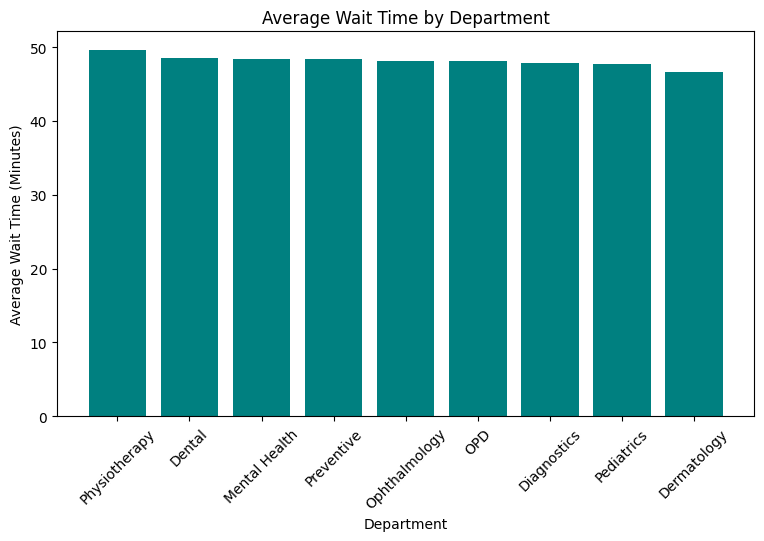

In [43]:
plt.figure(figsize=(9,5))

plt.bar(wait_time_mins.index,
        wait_time_mins.values,
        color="teal")

plt.title("Average Wait Time by Department")
plt.xlabel("Department")
plt.ylabel("Average Wait Time (Minutes)")

plt.xticks(rotation=45)

plt.show()

### Business Insight

The chart highlights differences in average waiting times across departments. Departments with higher average wait times may require process improvements, better scheduling, or additional staffing to reduce patient waiting time.

## 8. Follow-up Required Distribution

### Objective

Analyze the proportion of patients who require follow-up appointments after their hospital visit.

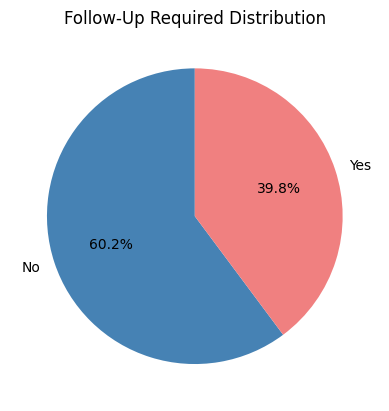

In [47]:
follow_up = df["Follow_Up_Required"].value_counts()

plt.pie(
    follow_up.values,
    labels=follow_up.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["steelblue", "lightcoral"]

)

plt.title("Follow-Up Required Distribution")

plt.show()

### Business Insight

The pie chart illustrates the proportion of patients requiring follow-up care compared to those who do not. This information helps estimate future patient workload and supports appointment scheduling and resource planning.

# Conclusion


### Key Findings

- Diagnostics and OPD consistently recorded the highest patient visit counts, indicating they are the busiest departments and may require greater staffing and resource allocation.
- Revenue analysis showed that a small number of departments and services contribute significantly to the hospital's overall revenue.
- Patient satisfaction scores were generally concentrated between 3.5 and 5, suggesting that most patients reported a positive healthcare experience.
- Average waiting times varied across departments, indicating opportunities to improve operational efficiency in departments with longer wait times.
- The follow-up distribution highlights the expected future patient workload and can support appointment planning and resource management.

### Recommendations

Based on these findings, hospital management should prioritize reducing waiting times in high-demand departments, continue monitoring patient satisfaction, and allocate resources according to patient volume and revenue contribution. Regular analysis of these key performance indicators can support better operational planning and improve the overall quality of healthcare services.

Overall, this project demonstrates how Python can be used to transform healthcare data into meaningful insights that support data-driven decision-making.